In [6]:
import MDAnalysis as mda
import nglview as nv

topology = "./case2/template/conf.gro"
trajectory = "./case2/all_traj/w11_all.xtc"
u = mda.Universe(topology, trajectory)
view = nv.show_mdanalysis(u)
view.add_representation("cartoon", selection="protein")
view

NGLWidget(max_frame=5)

number of native contacts = 43


/jet/home/lyuliyao/.conda/envs/pytorch/lib/python3.9/site-packages/MDAnalysis/topology/PDBParser.py:331: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using MDAnalysis.topology.guessers.
  warnings.warn("Element information is missing, elements attribute "


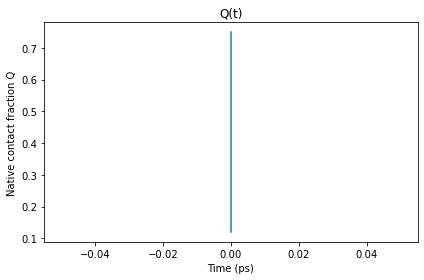

In [4]:
import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
from MDAnalysis.analysis.distances import distance_array
trajectory = f"./case2/all_traj/w11_all.xtc"
u = mda.Universe(topology, trajectory)
ref = mda.Universe("./case2/template/ref_ca.pdb")

ca = u.select_atoms("name CA")
ref_ca = ref.select_atoms("name CA")

assert len(ca) == len(ref_ca), "trajectory 和 reference 的 CA 数目不一致"

# 参考结构中的 CA-CA 距离矩阵
ref_d = distance_array(ref_ca.positions, ref_ca.positions)

# 只保留 native contacts:
# 1. 上三角，避免 (i,j) 和 (j,i) 重复
# 2. 排除近邻残基 |i-j| <= 3
# 3. 只保留参考结构中距离 < 8 Å 的接触
pairs = []
r0_native = []

nres = len(ref_ca)
for i in range(nres):
    for j in range(i + 4, nres):
        if ref_d[i, j] < 8.0:
            pairs.append((i, j))
            r0_native.append(ref_d[i, j])

pairs = np.array(pairs, dtype=int)
r0_native = np.array(r0_native)

print(f"number of native contacts = {len(pairs)}")

# 常用平滑指数
beta = 6

Q = []
times = []

for ts in u.trajectory:
    d = distance_array(ca.positions, ca.positions)
    dij = d[pairs[:, 0], pairs[:, 1]]

    # 以 reference contact distance 作为每对 contact 的 r0
    qij = 1.0 / (1.0 + (dij / (1.2 * r0_native)) ** beta)
    Q.append(np.mean(qij))
    times.append(ts.time)

Q = np.array(Q)
times = np.array(times)

plt.figure(figsize=(6, 4))
plt.plot(times, Q)
plt.xlabel("Time (ps)")
plt.ylabel("Native contact fraction Q")
plt.title("Q(t)")
plt.tight_layout()
plt.show()

In [7]:
u.trajectory

<XTCReader ./case2/all_traj/w11_all.xtc with 6 frames of 13809 atoms>